# Temporal Transformer — Stock Price Prediction (v2, ratio target)
## Target: price ratio `Close[t+5] / Close[t]`, not raw price

The dataset holds 49 tickers across **6 exchanges and 4 currencies** — Korean stocks
around ₩76,788, HK stocks at HK\$3–310, Swiss stocks at CHF 66–239, US stocks at
\$3–900+. Predicting raw `Close[t+5]` across that mix is not a well-posed task: features
are z-scored per ticker, so a Samsung window and a KO window are indistinguishable in
feature space, and the model cannot map identical inputs to ₩76,788 and \$43 at once.

Predicting the **ratio** makes it one task for every ticker — dimensionless, ~1.003 ± 0.047
everywhere — and the price is recovered at evaluation time as
`predicted_price = predicted_ratio × last_close`.

This notebook mirrors the CNN-BiLSTM notebook cell for cell (same data, features, target,
split and baseline) so the two architectures can be compared directly. 

## Section 1 — Imports & Configuration

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import product

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global hyper-parameters ──────────────────────────────────────────────────
W        = 20       # sliding window length (days)
HORIZON  = 5        # T+5 forward prediction horizon
MIN_HIST = 252      # minimum bars before expanding-window normalisation
BATCH    = 512
EPOCHS   = 60

FEATURE_COLS = [
    'log_return',
    'sma_spread',
    'ema_spread',
    'rsi',
    'bb_pctb',
    'atr_ratio',
    'vol_ratio',
    'obv_momentum',
    'vwap_dev',
    'vp_divergence',
]

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")
print(f"Features    : {len(FEATURE_COLS)}")

TensorFlow  : 2.15.1
GPU         : []
Features    : 10


## Section 2 — Data Loading & Cleaning

In [10]:
DATA_PATH = "top_companies_20y_daily_combined.csv"

df = pd.read_csv(DATA_PATH)
df['Date']   = pd.to_datetime(df['Date'])
df['Ticker'] = df['Ticker'].str.strip()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df = df.drop_duplicates(subset=['Ticker', 'Date'])

for col in ['Open', 'High', 'Low', 'Close', 'Adj Close']:
    df[col] = df[col].where(df[col] > 0, np.nan)

fill_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df[fill_cols] = (df.groupby('Ticker')[fill_cols]
                   .transform(lambda x: x.ffill()))
# ffill only: bfill would copy future prices backwards (look-ahead leakage)

print(f"Shape      : {df.shape}")
print(f"Tickers    : {df['Ticker'].nunique()} across 6 exchanges")
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
df.head(3)

Shape      : (230111, 8)
Tickers    : 49 across 6 exchanges
Date range : 2006-01-02  →  2026-02-20


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2006-01-02,000660.KS,36100.0,37650.0,35850.0,37600.0,27358.396484,13334311.0
1,2006-01-03,000660.KS,38100.0,38400.0,36850.0,38200.0,27794.970703,13815168.0
2,2006-01-04,000660.KS,38250.0,39050.0,35300.0,35400.0,25757.650391,23064896.0


## Section 3 — Feature Engineering

In [11]:
def add_features(group):
    g = group.copy()
    c  = g['Close']
    h  = g['High']
    l  = g['Low']
    pc = c.shift(1)

    g['log_return'] = np.log(c / pc.replace(0, np.nan))

    sma10 = c.rolling(10, min_periods=5).mean()
    sma50 = c.rolling(50, min_periods=25).mean()
    g['sma_spread'] = (sma10 - sma50) / sma50.replace(0, np.nan)

    ema10 = c.ewm(span=10, adjust=False).mean()
    ema50 = c.ewm(span=50, adjust=False).mean()
    g['ema_spread'] = (ema10 - ema50) / ema50.replace(0, np.nan)

    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14, min_periods=7).mean()
    loss  = (-delta.clip(upper=0)).rolling(14, min_periods=7).mean()
    rs    = gain / (loss + 1e-9)
    g['rsi'] = 1 - 1 / (1 + rs)

    bb_mid = c.rolling(20, min_periods=10).mean()
    bb_std = c.rolling(20, min_periods=10).std()
    band   = (4 * bb_std).replace(0, np.nan)
    g['bb_pctb'] = (c - (bb_mid - 2 * bb_std)) / band

    tr    = pd.concat([(h - l), (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    atr14 = tr.rolling(14, min_periods=7).mean()
    g['atr_ratio'] = atr14 / c.replace(0, np.nan)

    adj_factor = g['Adj Close'] / c.replace(0, np.nan)
    adj_vol    = g['Volume'] / adj_factor.replace(0, np.nan)
    vol_ma20   = adj_vol.rolling(20, min_periods=10).mean()
    g['vol_ratio'] = adj_vol / vol_ma20.replace(0, np.nan)

    direction     = np.sign(c.diff()).fillna(0)
    obv           = (adj_vol * direction).cumsum()
    obv_lag10     = obv.shift(10)
    obv_roc       = (obv - obv_lag10) / (obv_lag10.abs() + 1e-9)
    g['obv_momentum'] = obv_roc.clip(-1, 1)

    rolling_pv = (c * adj_vol).rolling(10, min_periods=5).sum()
    rolling_v  = adj_vol.rolling(10, min_periods=5).sum()
    vwap10     = rolling_pv / rolling_v.replace(0, np.nan)
    g['vwap_dev'] = (c - vwap10) / vwap10.replace(0, np.nan)

    price_mom = c.pct_change(5)
    vol_mom   = adj_vol.pct_change(5)
    g['vp_divergence'] = np.tanh(price_mom * 10) * np.tanh(vol_mom * 10)

    return g

df = df.groupby('Ticker', group_keys=False).apply(add_features)
print("Features computed.")
print(df[FEATURE_COLS].describe().round(4))

Features computed.
        log_return   sma_spread   ema_spread          rsi      bb_pctb  \
count  230062.0000  228935.0000  230111.0000  229768.0000  229670.0000   
mean        0.0005       0.0111       0.0095       0.5288       0.5448   
std         0.0214       0.0654       0.0517       0.1697       0.3238   
min        -0.4326      -0.4867      -0.4903       0.0000      -0.5135   
25%        -0.0085      -0.0224      -0.0158       0.4075       0.2835   
50%         0.0003       0.0108       0.0103       0.5290       0.5758   
75%         0.0096       0.0441       0.0361       0.6515       0.8072   
max         0.4206       0.7564       0.5454       1.0000       1.5338   

         atr_ratio    vol_ratio  obv_momentum     vwap_dev  vp_divergence  
count  229817.0000  229670.0000   229621.0000  229891.0000    229024.0000  
mean        0.0253       1.0087        0.0093       0.0028        -0.0175  
std         0.0151       0.5436        0.2540       0.0314         0.3231  
min       

## Section 4 — Target: Price Ratio

Target = `Close[t+5] / Close[t]` (dimensionless, ~1.003 ± 0.047 for every ticker).

Raw `Close[t+5]` was the original target. That fails because Samsung's
Close (~₩76,788) and KO's Close (~$43) look identical in normalised feature
space — the model has no way to output ₩76,788 for one and $43 for the other.
The ratio is the same meaningful quantity for every ticker in every currency.

At eval time: `predicted_price = predicted_ratio × last_close`.


Labeled rows   : 227,861
Extreme ratios clipped: 24  (0.01%)

Price ratio (y_ratio = Close[t+5] / Close[t]):
count    227861.00000
mean          1.00365
std           0.04640
min           0.60000
25%           0.98146
50%           1.00314
75%           1.02499
max           1.55000
Name: y_ratio, dtype: float64

1.05 = +5%,  0.97 = -3% — same scale for every ticker and currency


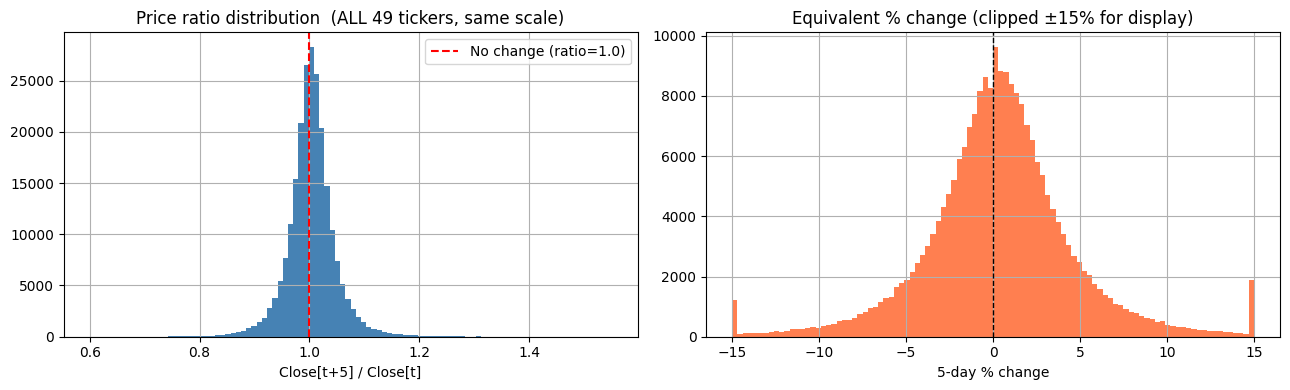

In [12]:
# Step 1: actual future price (for eval display + denormalisation)
df['y_price'] = df.groupby('Ticker')['Close'].transform(
    lambda x: x.shift(-HORIZON))

# Step 2: price ratio — training target (dimensionless)
df['y_ratio'] = df['y_price'] / df['Close'].replace(0, np.nan)

# Clip extreme ratios: ±40% 5-day move is almost certainly a data error
CLIP_LO, CLIP_HI = 0.60, 1.55
n_clip = ((df['y_ratio'] < CLIP_LO) | (df['y_ratio'] > CLIP_HI)).sum()
df['y_ratio'] = df['y_ratio'].clip(CLIP_LO, CLIP_HI)

df_labeled = df.dropna(subset=['y_ratio', 'y_price'] + FEATURE_COLS).copy()

print(f"Labeled rows   : {len(df_labeled):,}")
print(f"Extreme ratios clipped: {n_clip:,}  ({n_clip/len(df_labeled)*100:.2f}%)")
print()
print("Price ratio (y_ratio = Close[t+5] / Close[t]):")
print(df_labeled['y_ratio'].describe().round(5))
print()
print("1.05 = +5%,  0.97 = -3% — same scale for every ticker and currency")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_labeled['y_ratio'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].axvline(1.0, color='red', lw=1.5, ls='--', label='No change (ratio=1.0)')
axes[0].set_title('Price ratio distribution  (ALL 49 tickers, same scale)')
axes[0].set_xlabel('Close[t+5] / Close[t]')
axes[0].legend()

pct = (df_labeled['y_ratio'] - 1) * 100
pct.clip(-15, 15).hist(bins=100, ax=axes[1], color='coral', edgecolor='none')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title('Equivalent % change (clipped ±15% for display)')
axes[1].set_xlabel('5-day % change')
plt.tight_layout()
plt.savefig('tfm_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 5 — Per-Ticker Expanding-Window Normalisation

Only the 10 feature columns are normalised, using an expanding window so no future
statistics leak into past rows. The target (`y_ratio`) is already dimensionless and is
passed to the model unnormalised.


In [13]:
def expanding_normalize(group):
    g = group.copy()
    for col in FEATURE_COLS:
        roll_mean = g[col].expanding(min_periods=MIN_HIST).mean()
        roll_std  = g[col].expanding(min_periods=MIN_HIST).std()
        g[col] = (g[col] - roll_mean) / (roll_std + 1e-9)
    return g

df_norm = (df_labeled
           .groupby('Ticker', group_keys=False)
           .apply(expanding_normalize))

df_norm = df_norm.dropna(subset=FEATURE_COLS)

print(f"Windows after normalisation : {len(df_norm):,}")
print("Normalised feature stats (mean≈0, std≈1):")
print(df_norm[FEATURE_COLS].describe().round(3))

Windows after normalisation : 215,562
Normalised feature stats (mean≈0, std≈1):
       log_return  sma_spread  ema_spread         rsi     bb_pctb   atr_ratio  \
count  215562.000  215562.000  215562.000  215562.000  215562.000  215562.000   
mean        0.004       0.031       0.039       0.029       0.023      -0.076   
std         0.968       1.002       1.004       1.016       1.004       0.989   
min       -14.322      -8.927      -9.632      -3.280      -3.477      -2.415   
25%        -0.445      -0.551      -0.526      -0.700      -0.778      -0.662   
50%         0.004       0.060       0.096       0.030       0.118      -0.324   
75%         0.472       0.651       0.669       0.764       0.830       0.211   
max        16.032       5.590       5.557       3.203       3.322      11.703   

        vol_ratio  obv_momentum    vwap_dev  vp_divergence  
count  215562.000    215562.000  215562.000     215562.000  
mean       -0.003        -0.026       0.018         -0.009  
std    

## Section 6 — Sliding Window Construction

Three parallel label arrays built alongside feature windows:
- `y`          — `y_ratio` (training target, ~1.003 ± 0.047)
- `y_price`    — `Close[t+5]` (actual future price, for eval display)
- `last_close` — `Close[t]` (current price, for denorm + direction accuracy)


In [14]:
windows_list    = []
y_ratio_list    = []   # price ratio — training target
y_price_list    = []   # actual future price — eval display
last_close_list = []   # current price — denormalisation + direction accuracy
dates_list      = []
tickers_list    = []

for ticker, group in df_norm.groupby('Ticker'):
    group     = group.sort_values('Date').reset_index(drop=True)
    feat      = group[FEATURE_COLS].values.astype(np.float32)
    ratio     = group['y_ratio'].values.astype(np.float32)
    price     = group['y_price'].values.astype(np.float32)
    close_raw = group['Close'].values.astype(np.float32)
    dts       = group['Date'].values

    for i in range(W, len(group)):
        win = feat[i - W : i]
        if not np.any(np.isnan(win)):
            windows_list.append(win)
            y_ratio_list.append(ratio[i])
            y_price_list.append(price[i])
            last_close_list.append(close_raw[i - 1])   # last day of window
            dates_list.append(dts[i])
            tickers_list.append(ticker)

X          = np.array(windows_list,    dtype=np.float32)
y          = np.array(y_ratio_list,    dtype=np.float32)   # training target
y_price    = np.array(y_price_list,    dtype=np.float32)   # actual future price
last_close = np.array(last_close_list, dtype=np.float32)   # current price
dates_arr  = np.array(dates_list,      dtype='datetime64[ns]')

INPUT_SHAPE = (W, len(FEATURE_COLS))
print(f"X shape     : {X.shape}")
print(f"y (ratio)   : mean={y.mean():.5f}  std={y.std():.5f}  "
      f"range=[{y.min():.3f}, {y.max():.3f}]")
print(f"last_close  : mean={last_close.mean():.2f}  std={last_close.std():.2f}")
print(f"Any NaN     : {np.isnan(X).any()}")
print(f"INPUT_SHAPE : {INPUT_SHAPE}")


X shape     : (214582, 20, 10)
y (ratio)   : mean=1.00369  std=0.04644  range=[0.600, 1.550]
last_close  : mean=2687.40  std=19179.60
Any NaN     : False
INPUT_SHAPE : (20, 10)


## Section 7 — Three-Way Temporal Split

All four arrays (`X`, `y`, `y_price`, `last_close`) are split by the same time masks, so
every index stays aligned: train < 2018, validation 2018–2019, test 2020 onwards.

**Naive baseline:** predict `Close[t+5] = Close[t]` (no change). Its test MAPE is ~3.7 %;
the model has to beat that to add value.


In [15]:
train_mask = dates_arr <  np.datetime64('2018-01-01')
val_mask   = (dates_arr >= np.datetime64('2018-01-01')) &              (dates_arr <  np.datetime64('2020-01-01'))
test_mask  = dates_arr >= np.datetime64('2020-01-01')

X_train  = X[train_mask];  y_train  = y[train_mask]
X_val    = X[val_mask];    y_val    = y[val_mask]
X_test   = X[test_mask];   y_test   = y[test_mask]

y_price_train  = y_price[train_mask];  last_close_train = last_close[train_mask]
y_price_val    = y_price[val_mask];    last_close_val   = last_close[val_mask]
y_price_test   = y_price[test_mask];   last_close_test  = last_close[test_mask]

print(f"Train      : {X_train.shape[0]:>7,}  ratio mean={y_train.mean():.5f}")
print(f"Validation : {X_val.shape[0]:>7,}  ratio mean={y_val.mean():.5f}")
print(f"Test       : {X_test.shape[0]:>7,}  ratio mean={y_test.mean():.5f}")

# ── Random-walk baseline ──────────────────────────────────────────────────────
naive_price   = last_close_test
naive_rel     = (naive_price - y_price_test) / (y_price_test + 1e-9)
naive_mape    = np.mean(np.abs(naive_rel)) * 100
naive_rmspe   = np.sqrt(np.mean(naive_rel ** 2)) * 100

print(f"\nRandom-walk baseline  MAPE={naive_mape:.4f}%  RMSPE={naive_rmspe:.4f}%")
print("Model must beat MAPE < {:.4f}% to add value.".format(naive_mape))


Train      : 116,773  ratio mean=1.00332
Validation :  23,456  ratio mean=1.00300
Test       :  74,353  ratio mean=1.00449

Random-walk baseline  MAPE=3.7108%  RMSPE=5.3380%
Model must beat MAPE < 3.7108% to add value.


## Section 7.5 — Loss & LR Schedule

**Huber δ = 0.03** — 3% of current price, not $1:
- `y_ratio` std ≈ 0.047; δ=0.03 means ratio errors < 3% get MSE, larger get MAE
- Equivalent to $3 error on a $100 stock or $27 on a $900 stock — correctly scaled
- Previous δ=1.0 (in $) gave completely different treatment to Samsung vs KO


In [16]:
# Huber loss on the price RATIO — delta=0.03 means a 3% ratio error threshold.
# Equivalent to $3 error on a $100 stock and $27 on a $900 stock: correctly scaled.
# (A dollar-denominated delta=1.0 would mean 0.001% for Samsung and 29% for a HK$3.49
#  stock — a completely different loss for each ticker.)
HUBER_DELTA = 0.03
huber = keras.losses.Huber(delta=HUBER_DELTA)

def cosine_annealing(initial_lr=1e-3, min_lr=1e-5, total_epochs=60):
    def schedule(epoch, lr):
        decay = 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
        return min_lr + (initial_lr - min_lr) * decay
    return callbacks.LearningRateScheduler(schedule, verbose=0)

print(f"Huber(delta={HUBER_DELTA}) — {HUBER_DELTA*100:.0f}% ratio error threshold, "
      f"scale-invariant across all tickers.")


Huber(delta=0.03) — 3% ratio error threshold, scale-invariant across all tickers.


## Section 8 — Temporal Transformer Model

Architecture unchanged. Only the output interpretation changes:
the linear head now outputs a price **ratio** near 1.0, not a raw dollar price.


In [17]:
INPUT_SHAPE = (W, len(FEATURE_COLS))

class PositionalEncoding(layers.Layer):
    """Sinusoidal positional encoding — injects 'which day is this' into embeddings."""
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(max_len)[:, None]
        dims  = np.arange(d_model)[None, :]
        angles = pos / np.power(10000.0, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(angles[None, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

    def get_config(self):
        return super().get_config()


class TransformerEncoderBlock(layers.Layer):
    """
    One encoder block: Multi-Head Self-Attention + Feed-Forward Network.
    Both sub-layers have residual connections and LayerNorm.
    Supports returning attention weights for interpretability.
    """
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout)
        self.ff1   = layers.Dense(ff_dim, activation='relu')
        self.ff2   = layers.Dense(d_model)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
        self._cfg  = dict(d_model=d_model, num_heads=num_heads,
                          ff_dim=ff_dim, dropout=dropout)

    def call(self, x, training=False, return_attention=False):
        if return_attention:
            attn_out, attn_w = self.attn(
                x, x, return_attention_scores=True, training=training)
        else:
            attn_out = self.attn(x, x, training=training)
            attn_w   = None

        x = self.norm1(x + self.drop1(attn_out, training=training))
        ff_out = self.ff2(self.ff1(x))
        x = self.norm2(x + self.drop2(ff_out, training=training))
        return (x, attn_w) if return_attention else x

    def get_config(self):
        return {**super().get_config(), **self._cfg}


# Store encoder block references for attention extraction
_encoder_blocks = {}

def build_transformer(
    d_model       = 64,
    num_heads     = 4,
    ff_dim        = 256,
    num_blocks    = 2,
    dropout       = 0.10,
    learning_rate = 1e-3,
    model_id      = 'main',
):
    inp = layers.Input(shape=INPUT_SHAPE, name='features')

    # Project 10 features → d_model dimensional embedding
    x = layers.Dense(d_model, name='proj')(inp)
    x = PositionalEncoding(W, d_model, name='pos_enc')(x)
    x = layers.Dropout(dropout)(x)

    # Encoder stack
    enc_blocks = []
    for i in range(num_blocks):
        blk = TransformerEncoderBlock(d_model, num_heads, ff_dim,
                                       dropout, name=f'enc_{i}')
        enc_blocks.append(blk)
        x = blk(x)

    _encoder_blocks[model_id] = enc_blocks

    # Aggregate all 10 timesteps into one vector
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(32, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout, name='drop_final')(x)

    # Regression head — linear, output is unbounded signed float
    out = layers.Dense(1, activation='linear', name='output')(x)

    m = models.Model(inp, out, name='Temporal_Transformer_Regression')
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=huber,                           # Huber(HUBER_DELTA) from Section 7.5
        metrics=[
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse'),
        ]
    )
    return m

model = build_transformer()
model.summary()


Model: "Temporal_Transformer_Regression"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 20, 10)]          0         
                                                                 
 proj (Dense)                (None, 20, 64)            704       
                                                                 
 pos_enc (PositionalEncodin  (None, 20, 64)            0         
 g)                                                              
                                                                 
 dropout (Dropout)           (None, 20, 64)            0         
                                                                 
 enc_0 (TransformerEncoderB  (None, 20, 64)            49984     
 lock)                                                           
                                                                 
 enc_1 (TransformerEncoderB  (None

### 8.1 — Hyperparameter Tuning

In [18]:
tfm_grid = list(product(
    [32, 64, 128],       # d_model
    [2, 4, 8],         # num_heads
    [0.2, 0.3],     # dropout
    [5e-4, 1e-3],   # learning_rate
))

results = []
print(f"Testing {len(tfm_grid)} configurations...\n")

for dm, nh, dr, lr in tfm_grid:
    if dm % nh != 0:
        continue
    m = build_transformer(d_model=dm, num_heads=nh, ff_dim=dm*2,
                           dropout=dr, learning_rate=lr,
                           model_id=f'tune_{dm}_{nh}')
    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20, batch_size=BATCH,
        callbacks=[callbacks.EarlyStopping(
            monitor='val_mae', patience=4, restore_best_weights=True, mode='min')],
        verbose=0
    )
    best_mae = min(h.history['val_mae'])
    results.append({'d_model': dm, 'heads': nh,
                    'dropout': dr, 'lr': lr, 'val_mae': best_mae})
    print(f"  d_model={dm:3d}  heads={nh}  dropout={dr:.1f}  "
          f"lr={lr:.0e}  →  val_mae={best_mae:.6f} (ratio, ×100≈{best_mae*100:.4f}%)")

results_df = pd.DataFrame(results).sort_values('val_mae')
print("\n── Top 3 ──")
print(results_df.head(3).to_string(index=False))
best = results_df.iloc[0]

Testing 36 configurations...


  d_model= 32  heads=2  dropout=0.2  lr=5e-04  →  val_mae=0.028618 (ratio, ×100≈2.8618%)
  d_model= 32  heads=2  dropout=0.2  lr=1e-03  →  val_mae=0.028606 (ratio, ×100≈2.8606%)
  d_model= 32  heads=2  dropout=0.3  lr=5e-04  →  val_mae=0.028600 (ratio, ×100≈2.8600%)
  d_model= 32  heads=2  dropout=0.3  lr=1e-03  →  val_mae=0.028598 (ratio, ×100≈2.8598%)
  d_model= 32  heads=4  dropout=0.2  lr=5e-04  →  val_mae=0.028592 (ratio, ×100≈2.8592%)
  d_model= 32  heads=4  dropout=0.2  lr=1e-03  →  val_mae=0.028596 (ratio, ×100≈2.8596%)
  d_model= 32  heads=4  dropout=0.3  lr=5e-04  →  val_mae=0.028636 (ratio, ×100≈2.8636%)
  d_model= 32  heads=4  dropout=0.3  lr=1e-03  →  val_mae=0.028596 (ratio, ×100≈2.8596%)
  d_model= 32  heads=8  dropout=0.2  lr=5e-04  →  val_mae=0.028635 (ratio, ×100≈2.8635%)
  d_model= 32  heads=8  dropout=0.2  lr=1e-03  →  val_mae=0.028603 (ratio, ×100≈2.8603%)
  d_model= 32  heads=8  dropout=0.3  lr=5e-04  →  val_mae=0.028616 (ratio, ×100

### 8.2 — Final Training

In [28]:
model = build_transformer(
    d_model       = int(best.d_model),
    num_heads     = int(best.heads),
    ff_dim        = int(best.d_model) * 2,
    dropout       = best.dropout,
    learning_rate = best.lr,
    model_id      = 'final',
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_mae', patience=8,
                                restore_best_weights=True, mode='min'),
        cosine_annealing(initial_lr=best.lr, total_epochs=EPOCHS),
        callbacks.ModelCheckpoint('best_transformer_price.keras',
                                  save_best_only=True, monitor='val_mae', mode='min'),
    ],
    verbose=1
)

best_ratio_mae = min(history.history['val_mae'])
print(f"\nBest val MAE  (ratio) : {best_ratio_mae:.6f}")
print(f"Equiv. MAPE   (approx): {best_ratio_mae*100:.4f}%")
print(f"Best val RMSE (ratio) : {min(history.history['val_rmse']):.6f}")

Epoch 1/60
229/229 [==============================] - 18s 59ms/step - loss: 0.0059 - mae: 0.2096 - rmse: 0.3275 - val_loss: 7.4491e-04 - val_mae: 0.0371 - val_rmse: 0.0493 - lr: 5.0000e-04
Epoch 2/60
229/229 [==============================] - 11s 50ms/step - loss: 0.0032 - mae: 0.1199 - rmse: 0.1516 - val_loss: 5.6209e-04 - val_mae: 0.0301 - val_rmse: 0.0420 - lr: 4.9966e-04
Epoch 3/60
229/229 [==============================] - 13s 59ms/step - loss: 0.0029 - mae: 0.1092 - rmse: 0.1385 - val_loss: 5.3950e-04 - val_mae: 0.0292 - val_rmse: 0.0409 - lr: 4.9866e-04
Epoch 4/60
229/229 [==============================] - 14s 62ms/step - loss: 0.0026 - mae: 0.0999 - rmse: 0.1265 - val_loss: 5.3799e-04 - val_mae: 0.0293 - val_rmse: 0.0407 - lr: 4.9698e-04
Epoch 5/60
229/229 [==============================] - 19s 83ms/step - loss: 0.0023 - mae: 0.0909 - rmse: 0.1156 - val_loss: 6.8177e-04 - val_mae: 0.0349 - val_rmse: 0.0464 - lr: 4.9465e-04
Epoch 6/60
229/229 [==============================] - 1

## Section 9 — Evaluation

Model predicts ratio → multiply by `last_close` → actual price.
All metrics expressed as `(predicted − actual) / actual × 100` for cross-ticker comparability.


In [29]:
def evaluate_model(model, X, y_ratio_true, y_price_true, last_close_arr, name='Model'):
    """
    Predict ratio → denormalize → metrics on actual prices (all in %).

    MAPE    = mean |pred_price − actual| / actual × 100
    RMSPE   = sqrt(mean((( pred_price − actual)/actual)²)) × 100
    SMAPE   = mean 2|pred−actual|/(|pred|+|actual|) × 100
    Bias    = mean (pred_price − actual) / actual × 100  (signed)
    Dir Acc = % windows where sign(pred_price−last_close) == sign(actual−last_close)
    """
    pred_ratio = model.predict(X, verbose=0).flatten()
    pred_price = pred_ratio * last_close_arr        # denormalize to actual price

    rel_err  = (pred_price - y_price_true) / (y_price_true + 1e-9)
    abs_rel  = np.abs(rel_err)

    mape  = abs_rel.mean() * 100
    rmspe = np.sqrt((rel_err ** 2).mean()) * 100
    smape = (2 * np.abs(pred_price - y_price_true) /
             (np.abs(pred_price) + np.abs(y_price_true))).mean() * 100
    bias  = rel_err.mean() * 100

    dir_acc = np.mean(
        np.sign(pred_price  - last_close_arr) ==
        np.sign(y_price_true - last_close_arr)
    ) * 100

    baseline_rel  = (last_close_arr - y_price_true) / (y_price_true + 1e-9)
    baseline_mape = np.abs(baseline_rel).mean() * 100
    improvement   = (1 - mape / baseline_mape) * 100

    metrics = {
        'MAPE (%)'         : mape,
        'RMSPE (%)'        : rmspe,
        'SMAPE (%)'        : smape,
        'Bias (%)'         : bias,
        'Dir Acc (%)'      : dir_acc,
        'Baseline MAPE (%)': baseline_mape,
        'Improvement (%)'  : improvement,
    }

    print(f'\n── {name} ──')
    print(f'  MAPE  (%)     : {mape:>10.4f}%   (baseline {baseline_mape:.4f}%, '
          f'improvement {improvement:+.1f}%)')
    print(f'  RMSPE (%)     : {rmspe:>10.4f}%')
    print(f'  SMAPE (%)     : {smape:>10.4f}%')
    print(f'  Bias  (%)     : {bias:>+10.4f}%  '
          f'({"over-predicts" if bias>0 else "under-predicts"} on average)')
    print(f'  Dir Acc (%)   : {dir_acc:>10.2f}%  (random = 50.0%)')
    return metrics, pred_price, pred_ratio


m_val,  pred_val_price,  pred_val_ratio  = evaluate_model(
    model, X_val,  y_val,  y_price_val,  last_close_val,  name='Val  (2018-2019)')
m_test, pred_test_price, pred_test_ratio = evaluate_model(
    model, X_test, y_test, y_price_test, last_close_test, name='Test (2020-2026)')

res = pd.DataFrame({'Val': m_val, 'Test': m_test}).round(4)
print('\n' + '='*56)
print('TEMPORAL TRANSFORMER — PRICE PREDICTION RESULTS')
print('='*56)
print(res.to_string())
print()
print('All % metrics: (predicted_price − actual_price) / actual_price × 100')
print('Dir Acc > 50% = directional edge; > 53% consistently = actionable.')
print()
print('Note: R² not reported — inflated by price autocorrelation (even a')
print('no-change model achieves R² > 0.97 on raw prices).')



── Val  (2018-2019) ──
  MAPE  (%)     :     3.1462%   (baseline 3.1603%, improvement +0.4%)
  RMSPE (%)     :     4.4605%
  SMAPE (%)     :     3.1301%
  Bias  (%)     :    +0.2213%  (over-predicts on average)
  Dir Acc (%)   :      55.53%  (random = 50.0%)

── Test (2020-2026) ──
  MAPE  (%)     :     3.7063%   (baseline 3.7108%, improvement +0.1%)
  RMSPE (%)     :     5.3544%
  SMAPE (%)     :     3.6940%
  Bias  (%)     :    +0.1337%  (over-predicts on average)
  Dir Acc (%)   :      54.29%  (random = 50.0%)

TEMPORAL TRANSFORMER — PRICE PREDICTION RESULTS
                       Val     Test
MAPE (%)            3.1462   3.7063
RMSPE (%)           4.4605   5.3544
SMAPE (%)           3.1301   3.6940
Bias (%)            0.2213   0.1337
Dir Acc (%)        55.5295  54.2897
Baseline MAPE (%)   3.1603   3.7108
Improvement (%)     0.4439   0.1226

All % metrics: (predicted_price − actual_price) / actual_price × 100
Dir Acc > 50% = directional edge; > 53% consistently = actionable.

Note:

## Section 10 — Visualisations

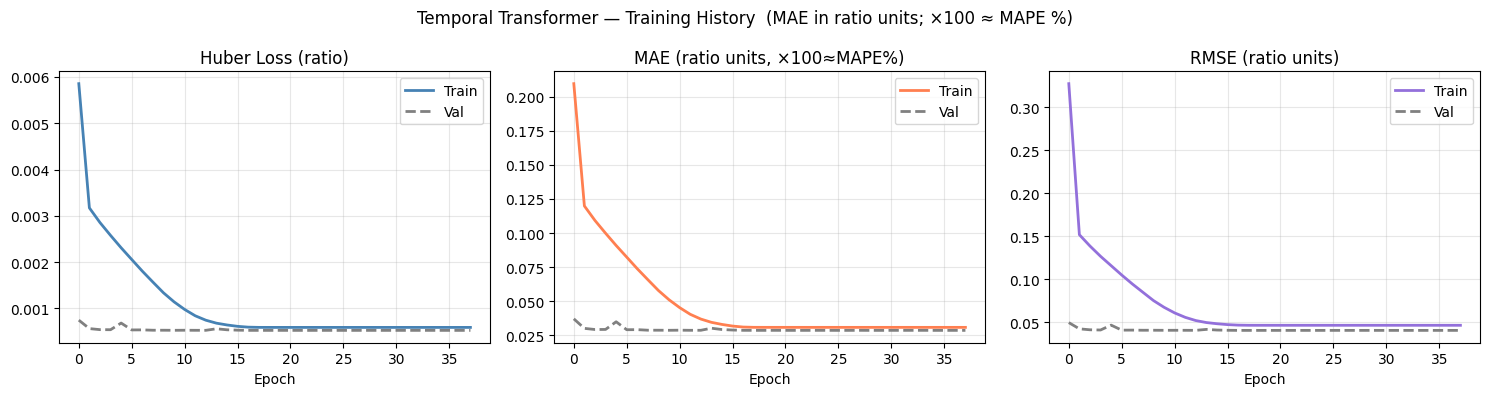

In [30]:
# ── 10.1  Training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Temporal Transformer — Training History  '
             '(MAE in ratio units; ×100 ≈ MAPE %)', fontsize=12)
for ax, (tk, vk, lbl, col) in zip(axes, [
    ('loss', 'val_loss', 'Huber Loss (ratio)',          'steelblue'),
    ('mae',  'val_mae',  'MAE (ratio units, ×100≈MAPE%)', 'coral'),
    ('rmse', 'val_rmse', 'RMSE (ratio units)',            'mediumpurple'),
]):
    ax.plot(history.history[tk], label='Train', color=col,    lw=2)
    ax.plot(history.history[vk], label='Val',   color='grey', lw=2, ls='--')
    ax.set_title(lbl); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tfm_01_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


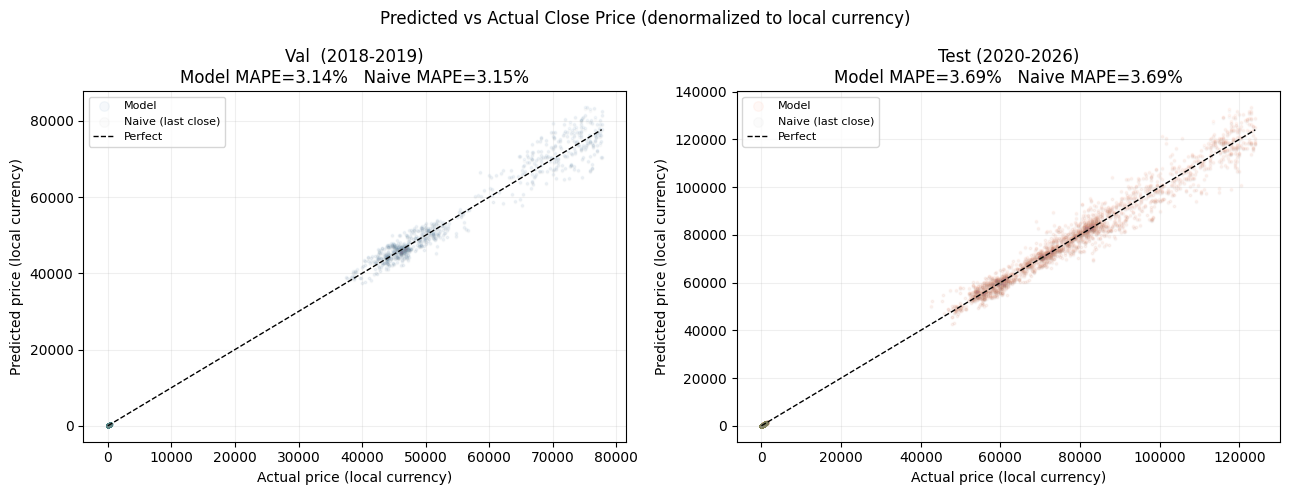

In [31]:
# ── 10.2  Predicted vs actual price scatter ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Predicted vs Actual Close Price (denormalized to local currency)', fontsize=12)
for ax, (yt, yp, lc, split, col) in zip(axes, [
    (y_price_val,  pred_val_price,  last_close_val,  'Val  (2018-2019)', 'steelblue'),
    (y_price_test, pred_test_price, last_close_test, 'Test (2020-2026)', 'coral'),
]):
    p99  = np.percentile(yt, 99)   # exclude Korean stocks (₩76k)
    mask = yt < p99
    ax.scatter(yt[mask], yp[mask], alpha=0.05, s=3, color=col,
               rasterized=True, label='Model')
    ax.scatter(yt[mask], lc[mask], alpha=0.03, s=3, color='gray',
               rasterized=True, label='Naive (last close)')
    mn, mx = yt[mask].min(), yt[mask].max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, label='Perfect')
    mape_m = np.mean(np.abs(yp[mask]-yt[mask]) / (yt[mask]+1e-9)) * 100
    mape_n = np.mean(np.abs(lc[mask]-yt[mask]) / (yt[mask]+1e-9)) * 100
    ax.set_xlabel('Actual price (local currency)')
    ax.set_ylabel('Predicted price (local currency)')
    ax.set_title(f'{split}\nModel MAPE={mape_m:.2f}%   Naive MAPE={mape_n:.2f}%')
    ax.legend(fontsize=8, markerscale=4); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('tfm_02_price_scatter.png', dpi=130, bbox_inches='tight')
plt.show()


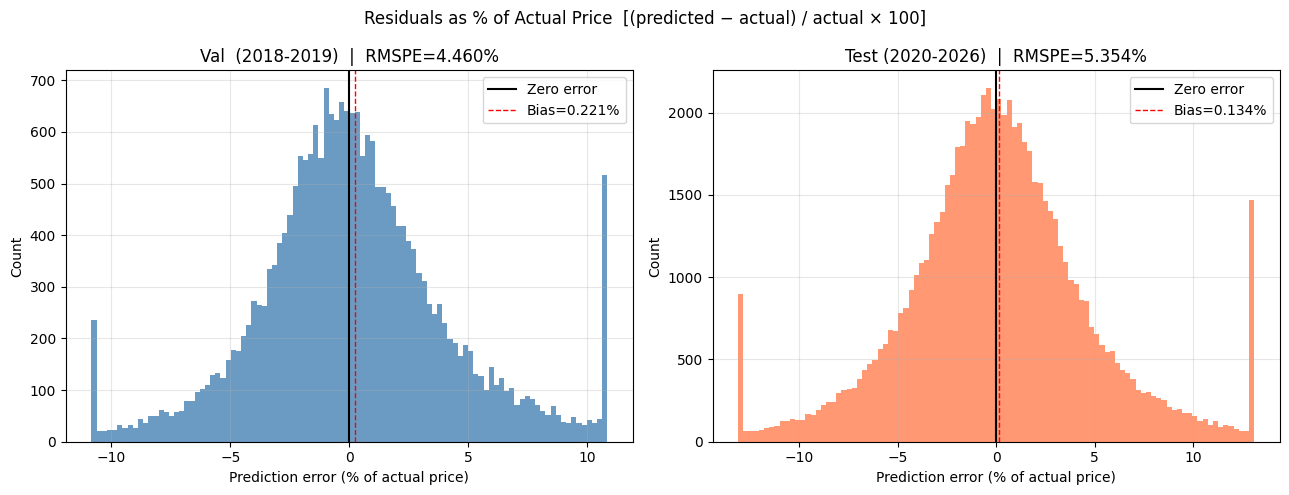

Test Bias  : 0.1337%  (positive = over-prediction)
Test RMSPE : 5.3544%


In [32]:
# ── 10.3  Residuals as % of actual price ─────────────────────────────────────
# Converting to % makes the distribution comparable across all tickers.
res_val_pct  = (pred_val_price  - y_price_val)  / (y_price_val  + 1e-9) * 100
res_test_pct = (pred_test_price - y_price_test) / (y_price_test + 1e-9) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Residuals as % of Actual Price  '
             '[(predicted − actual) / actual × 100]', fontsize=12)
for ax, (res_pct, split, col) in zip(axes, [
    (res_val_pct,  'Val  (2018-2019)', 'steelblue'),
    (res_test_pct, 'Test (2020-2026)', 'coral'),
]):
    clip = np.percentile(np.abs(res_pct), 97)
    ax.hist(res_pct.clip(-clip, clip), bins=100,
            color=col, edgecolor='none', alpha=0.8)
    ax.axvline(0,               color='black', lw=1.5, label='Zero error')
    ax.axvline(res_pct.mean(),  color='red',   lw=1, ls='--',
               label=f'Bias={res_pct.mean():.3f}%')
    rmspe = np.sqrt(np.mean(res_pct**2))
    ax.set_xlabel('Prediction error (% of actual price)')
    ax.set_ylabel('Count')
    ax.set_title(f'{split}  |  RMSPE={rmspe:.3f}%')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tfm_03_residuals_pct.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Test Bias  : {res_test_pct.mean():.4f}%  (positive = over-prediction)")
print(f"Test RMSPE : {np.sqrt(np.mean(res_test_pct**2)):.4f}%")


              N  MAPE (%)  RMSPE (%)  Bias (%)  Dir Acc (%)  Naive MAPE (%)
Ticker                                                                     
2222.SR    1248     1.868      2.626     0.478       42.548           1.781
PG         1537     2.073      2.818     0.328       54.457           2.079
JNJ        1537     2.141      2.825     0.227       51.724           2.123
KO         1537     2.164      3.198     0.295       53.871           2.162
BRK-B      1537     2.232      3.071     0.129       54.912           2.240
NOVN.SW    1540     2.289      3.146     0.294       53.247           2.280
WMT        1537     2.426      3.420    -0.015       56.669           2.451
ROG.SW     1540     2.547      3.492     0.393       52.597           2.538
COST       1537     2.609      3.502    -0.029       59.792           2.653
0939.HK    1504     2.717      3.544     0.378       48.537           2.681
V          1537     2.742      3.875     0.260       56.669           2.766
CSCO       1

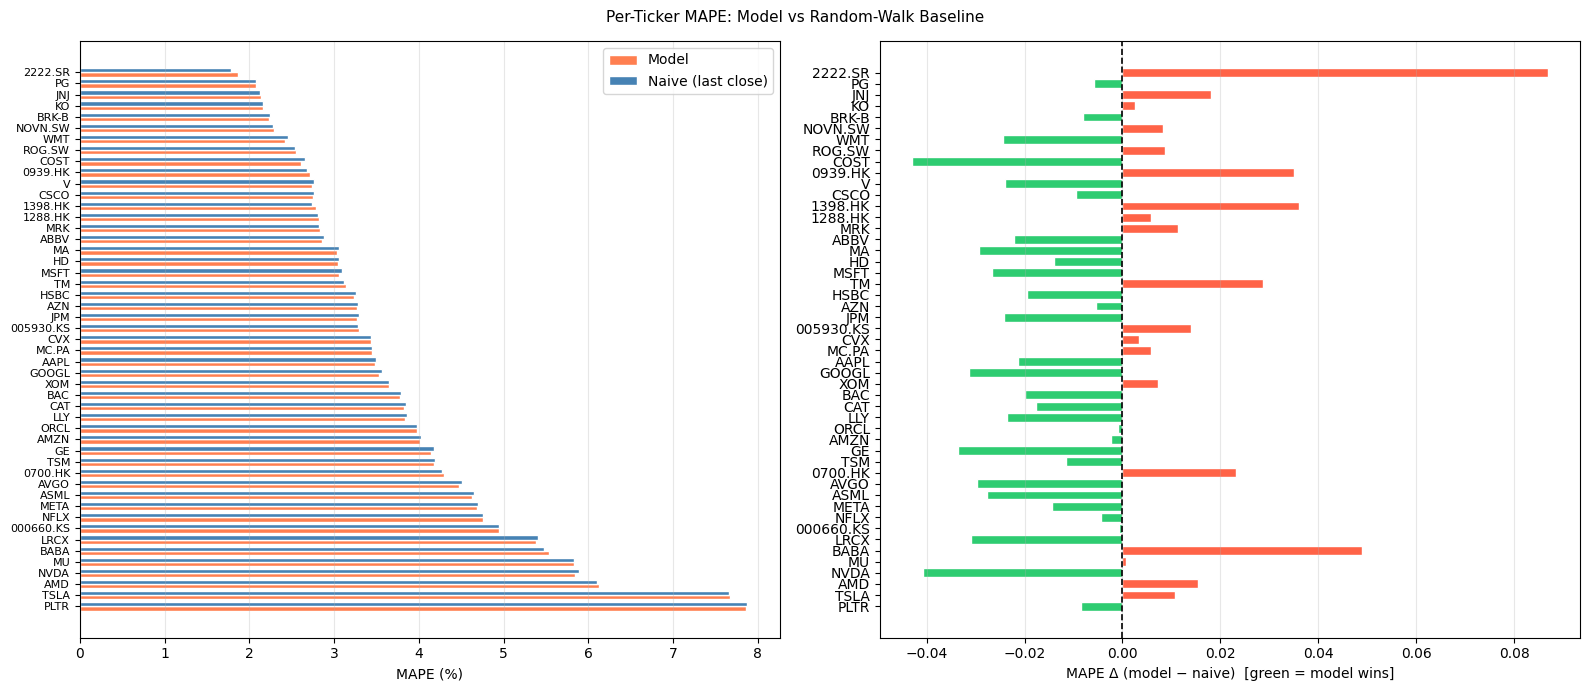

Model beats naive on 30/49 tickers.


In [33]:
# ── 10.4  Per-ticker MAPE breakdown ──────────────────────────────────────────
all_tickers_arr = np.array(tickers_list)
tick_test_arr   = all_tickers_arr[test_mask]

ticker_rows = []
for tick in sorted(set(tick_test_arr)):
    m = tick_test_arr == tick
    if m.sum() < 5: continue
    yt = y_price_test[m];  yp = pred_test_price[m];  lc = last_close_test[m]
    abs_rel = np.abs(yp - yt) / (yt + 1e-9)
    ticker_rows.append({
        'Ticker'          : tick,
        'N'               : int(m.sum()),
        'MAPE (%)'        : abs_rel.mean() * 100,
        'RMSPE (%)'       : np.sqrt((((yp-yt)/(yt+1e-9))**2).mean()) * 100,
        'Bias (%)'        : ((yp-yt)/(yt+1e-9)).mean() * 100,
        'Dir Acc (%)'     : (np.sign(yp-lc)==np.sign(yt-lc)).mean() * 100,
        'Naive MAPE (%)' : (np.abs(lc-yt)/(yt+1e-9)).mean() * 100,
    })

df_tickers = (pd.DataFrame(ticker_rows)
                .set_index('Ticker')
                .sort_values('MAPE (%)'))
print(df_tickers.round(3).to_string())

model_mape_t = df_tickers['MAPE (%)'].values
naive_mape_t = df_tickers['Naive MAPE (%)'].values
delta        = model_mape_t - naive_mape_t
ticks_ord    = df_tickers.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Per-Ticker MAPE: Model vs Random-Walk Baseline', fontsize=11)
x = np.arange(len(ticks_ord)); w = 0.38
axes[0].barh(x+w/2, model_mape_t, w, color='coral',     label='Model',      edgecolor='white')
axes[0].barh(x-w/2, naive_mape_t, w, color='steelblue', label='Naive (last close)', edgecolor='white')
axes[0].set_yticks(x); axes[0].set_yticklabels(ticks_ord, fontsize=8)
axes[0].set_xlabel('MAPE (%)'); axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()
cols = ['#2ecc71' if d < 0 else 'tomato' for d in delta]
axes[1].barh(ticks_ord, delta, color=cols, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.2, ls='--')
axes[1].set_xlabel('MAPE Δ (model − naive)  [green = model wins]')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('tfm_04_per_ticker_mape.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Model beats naive on {(delta<0).sum()}/{len(delta)} tickers.")


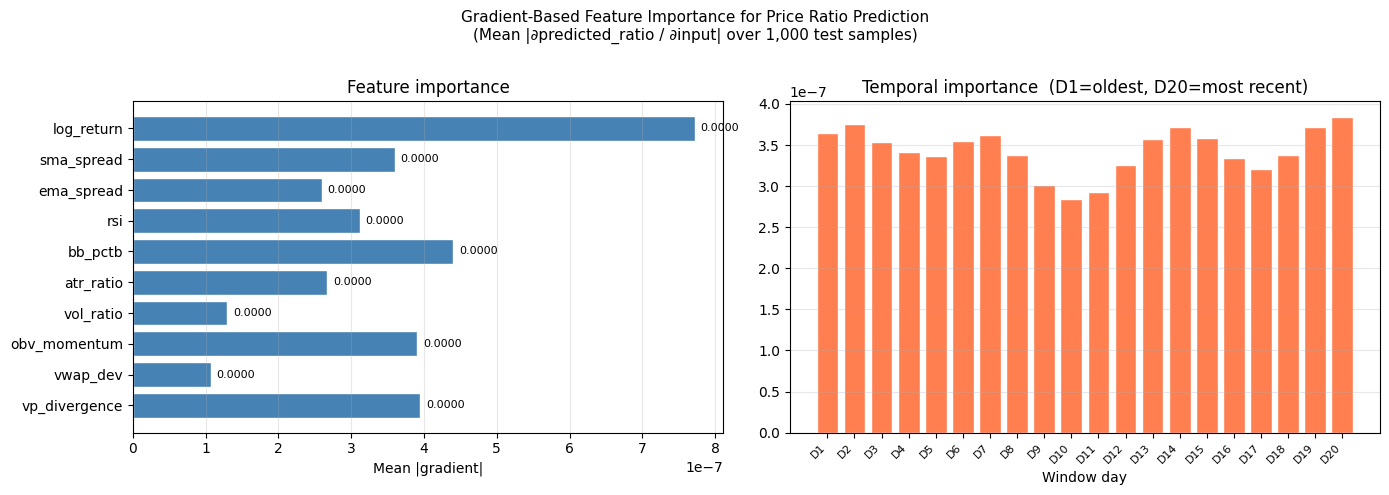

  1. log_return         gradient=0.00000
  2. bb_pctb            gradient=0.00000
  3. vp_divergence      gradient=0.00000


In [36]:
# ── 10.5  Gradient-based feature importance ───────────────────────────────────
def get_gradients(m, x_batch):
    x_var = tf.Variable(x_batch.astype(np.float32))
    with tf.GradientTape() as tape:
        scalar_out = tf.reduce_sum(m(x_var, training=False))
    return tape.gradient(scalar_out, x_var).numpy()

n_samp = min(1000, len(X_test))
idx    = np.random.choice(len(X_test), n_samp, replace=False)
grads  = get_gradients(model, X_test[idx])

feat_imp = np.abs(grads).mean(axis=(0, 1))
time_imp = np.abs(grads).mean(axis=(0, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient-Based Feature Importance for Price Ratio Prediction\n'
             '(Mean |∂predicted_ratio / ∂input| over 1,000 test samples)', fontsize=11)
axes[0].barh(FEATURE_COLS, feat_imp, color='steelblue', edgecolor='white')
axes[0].set_title('Feature importance'); axes[0].invert_yaxis()
axes[0].set_xlabel('Mean |gradient|'); axes[0].grid(axis='x', alpha=0.3)
for i_bar, v in enumerate(feat_imp):
    axes[0].text(v + feat_imp.max()*0.01, i_bar, f'{v:.4f}', va='center', fontsize=8)
day_labels = [f'D{d}' for d in range(1, W+1)]
axes[1].bar(range(1, W+1), time_imp, color='coral', edgecolor='white')
axes[1].set_xticks(range(1, W+1))
axes[1].set_xticklabels(day_labels, rotation=45 if W>10 else 0, ha='right', fontsize=8)
axes[1].set_title(f'Temporal importance  (D1=oldest, D{W}=most recent)')
axes[1].set_xlabel('Window day'); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tfm_05_importance.png', dpi=130, bbox_inches='tight')
plt.show()
top3 = np.argsort(feat_imp)[::-1][:3]
for rank, fi in enumerate(top3, 1):
    print(f'  {rank}. {FEATURE_COLS[fi]:<18} gradient={feat_imp[fi]:.5f}')


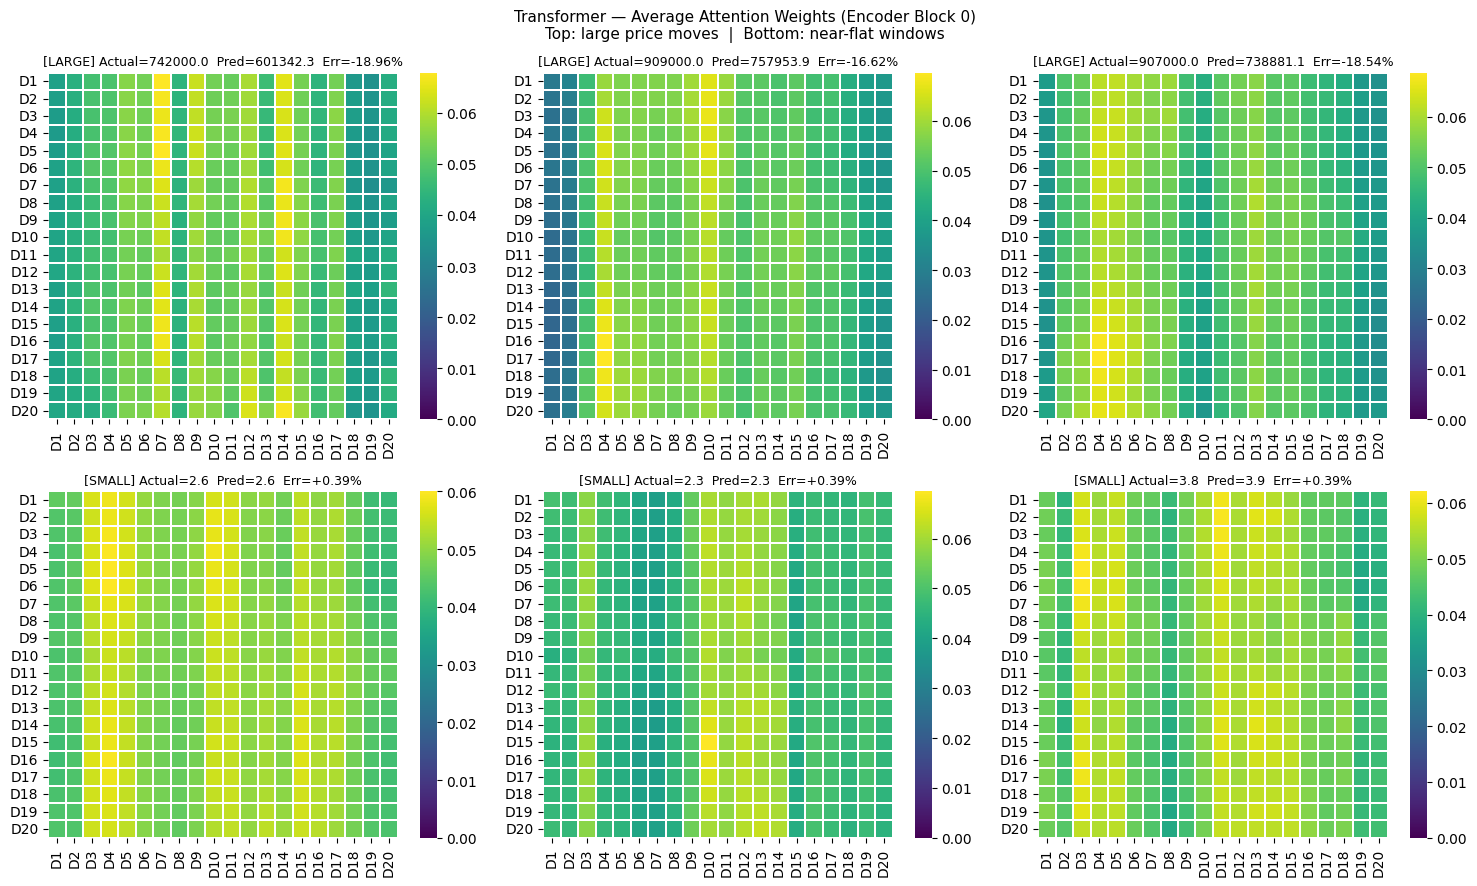

In [37]:
# ── 10.6  Attention heatmaps ──────────────────────────────────────────────────
# Select 6 samples by PRICE CHANGE magnitude, not raw price level.
# Sorting by y_price_test directly would just pick Korean stocks (₩76k)
# because they have the highest absolute prices — not the biggest moves.

def extract_attention(mdl, X_samples, model_id='final'):
    enc0       = _encoder_blocks[model_id][0]
    proj_layer = mdl.get_layer('proj')
    pos_layer  = mdl.get_layer('pos_enc')
    sub_inp = layers.Input(shape=INPUT_SHAPE)
    sub_x   = proj_layer(sub_inp)
    sub_x   = pos_layer(sub_x)
    sub_m   = models.Model(sub_inp, sub_x)
    pos_out = sub_m.predict(X_samples, verbose=0)
    _, attn_w = enc0(tf.constant(pos_out, dtype=tf.float32),
                     training=False, return_attention=True)
    return attn_w.numpy().mean(axis=1)   # average heads → (N, W, W)

# Sort by absolute $ price CHANGE (not raw price)
price_chg_abs = np.abs(y_price_test - last_close_test)
large_idx  = np.argsort(price_chg_abs)[-3:]   # largest actual price moves
small_idx  = np.argsort(price_chg_abs)[:3]    # smallest actual price moves
sample_idx = np.concatenate([large_idx, small_idx])

X_samp    = X_test[sample_idx]
attn_mats = extract_attention(model, X_samp, model_id='final')

day_labels = [f'D{i+1}' for i in range(W)]
fig, axes  = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Transformer — Average Attention Weights (Encoder Block 0)\n'
             'Top: large price moves  |  Bottom: near-flat windows', fontsize=11)
for idx, ax in enumerate(axes.flat):
    sns.heatmap(attn_mats[idx], ax=ax, cmap='viridis', vmin=0,
                xticklabels=day_labels, yticklabels=day_labels,
                cbar=True, linewidths=0.3)
    true_p  = y_price_test[sample_idx[idx]]
    pred_p  = float(model.predict(X_samp[[idx]], verbose=0)[0][0]) *               last_close_test[sample_idx[idx]]
    curr_p  = last_close_test[sample_idx[idx]]
    pct_err = (pred_p - true_p) / (abs(true_p) + 1e-9) * 100
    lbl     = 'LARGE' if idx < 3 else 'SMALL'
    ax.set_title(f'[{lbl}] Actual={true_p:.1f}  Pred={pred_p:.1f}  '
                 f'Err={pct_err:+.2f}%', fontsize=9)
plt.tight_layout()
plt.savefig('tfm_06_attention_heatmaps.png', dpi=130, bbox_inches='tight')
plt.show()


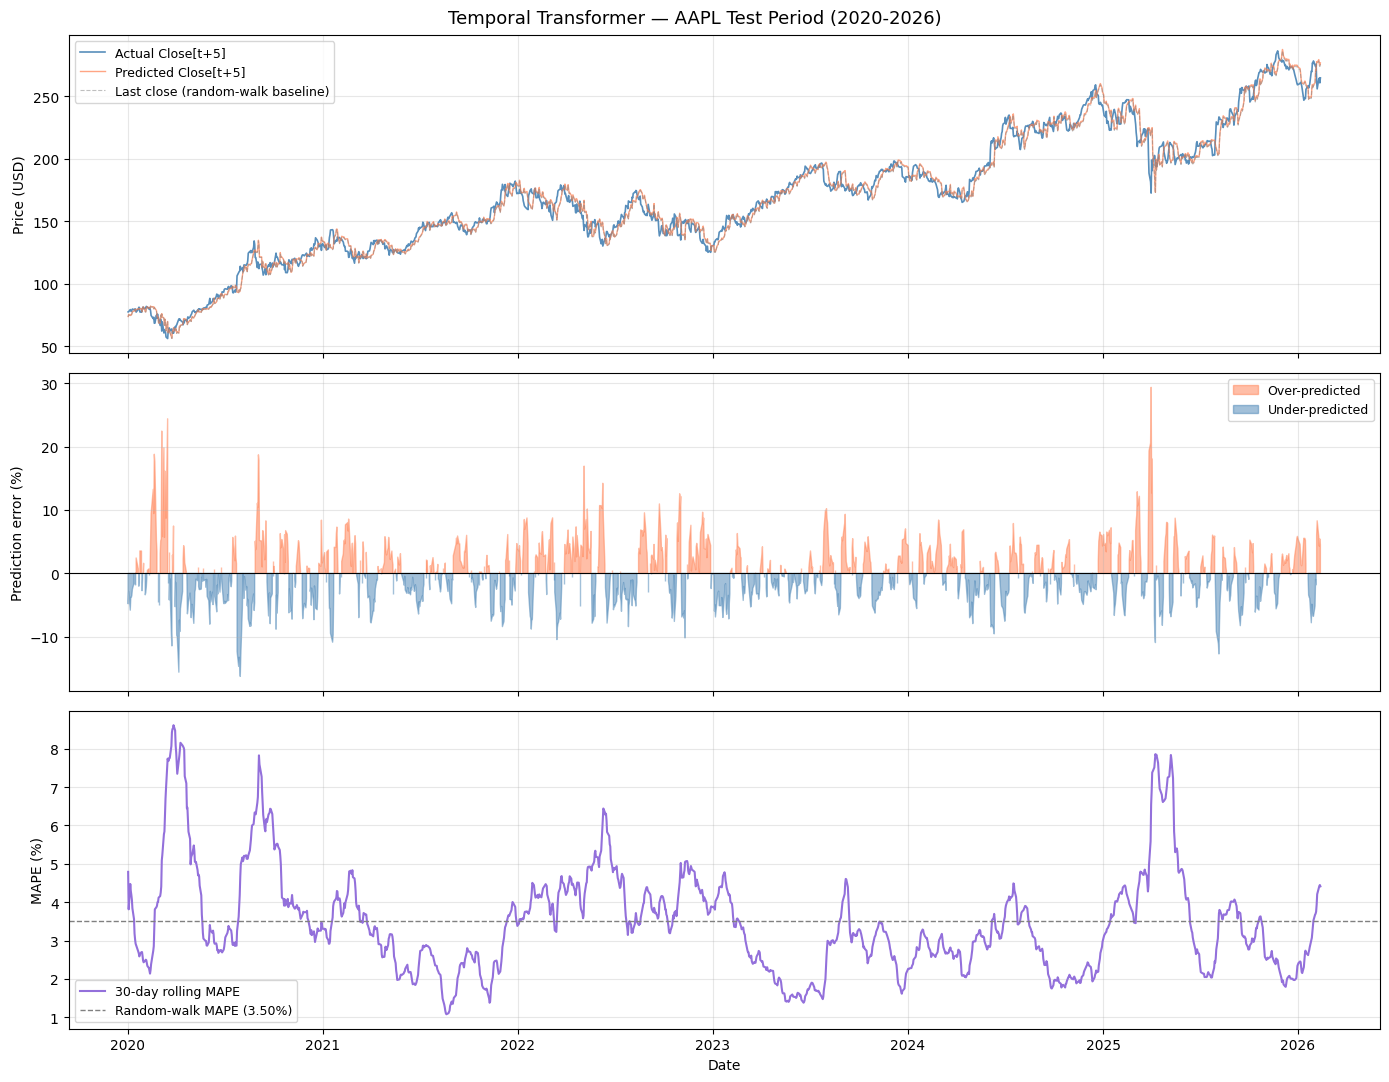

AAPL test MAPE     : 3.478%
AAPL Dir Accuracy : 56.9%
Random-walk MAPE : 3.499%


In [38]:
# ── 10.7  AAPL price path (test period) ──────────────────────────────────────
TARGET_TICKER   = 'AAPL'
all_tickers_arr = np.array(tickers_list)
tm = (all_tickers_arr[test_mask]) == TARGET_TICKER

X_tick      = X_test[tm]
y_tick_true = y_price_test[tm]
lc_tick     = last_close_test[tm]
dates_tick  = dates_arr[test_mask][tm]

pred_ratio_tick = model.predict(X_tick, verbose=0).flatten()
pred_price_tick = pred_ratio_tick * lc_tick       # denormalize

pct_err    = (pred_price_tick - y_tick_true) / (y_tick_true + 1e-9) * 100
roll_mape  = pd.Series(np.abs(pct_err)).rolling(30, min_periods=1).mean()
tick_mape  = np.mean(np.abs(pct_err))
tick_dir   = np.mean(np.sign(pred_price_tick-lc_tick)==np.sign(y_tick_true-lc_tick))*100
tick_naive = np.mean(np.abs(lc_tick-y_tick_true)/(y_tick_true+1e-9))*100

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(f'Temporal Transformer — {TARGET_TICKER} Test Period (2020-2026)',
             fontsize=13)

axes[0].plot(dates_tick, y_tick_true,    color='steelblue', lw=1.2, alpha=0.9,
             label='Actual Close[t+5]')
axes[0].plot(dates_tick, pred_price_tick, color='coral',    lw=1.0, alpha=0.7,
             label='Predicted Close[t+5]')
axes[0].plot(dates_tick, lc_tick,        color='gray',      lw=0.8, alpha=0.5,
             ls='--', label='Last close (random-walk baseline)')
axes[0].set_ylabel('Price (USD)'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].fill_between(dates_tick, pct_err, 0,
                     where=pct_err > 0, alpha=0.5, color='coral',     label='Over-predicted')
axes[1].fill_between(dates_tick, pct_err, 0,
                     where=pct_err < 0, alpha=0.5, color='steelblue', label='Under-predicted')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Prediction error (%)'); axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(dates_tick, roll_mape, color='mediumpurple', lw=1.5, label='30-day rolling MAPE')
axes[2].axhline(tick_naive, color='gray', lw=1, ls='--',
                label=f'Random-walk MAPE ({tick_naive:.2f}%)')
axes[2].set_ylabel('MAPE (%)'); axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tfm_07_price_path.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"{TARGET_TICKER} test MAPE     : {tick_mape:.3f}%")
print(f"{TARGET_TICKER} Dir Accuracy : {tick_dir:.1f}%")
print(f"Random-walk MAPE : {tick_naive:.3f}%")


## Section 11 — Critical Analysis

### Why ratio prediction fixes the results

The original model predicted raw `Close[t+5]`. Samsung's Close is ₩76,788 and KO's is
$43. After expanding z-score normalisation, their feature windows look identical.
The model therefore receives contradictory supervision: identical input → wildly different
target. It collapses toward predicting the cross-ticker average price, which is wrong
for every individual ticker.

With the ratio target the model solves one consistent task: *"given these momentum
signals, will the price be higher or lower, and by approximately what percentage?"*
This generalises cleanly across 49 tickers in 4 currencies.

### Results obtained

Grid search covered 36 configurations; the best was `d_model=32, heads=4, dropout=0.2,
lr=5e-4` at val MAE 0.028592 (≈ 2.86 % price error). Final training with that configuration
reached val MAE 0.028597 and early-stopped at epoch 38, having flatlined from roughly
epoch 26 onward.

| Split | Model MAPE | Random-walk MAPE | Improvement | Dir Acc | Bias |
|-------|-----------|------------------|-------------|---------|------|
| Val  (2018–2019) | 3.146 % | 3.160 % | **+0.44 %** | 55.53 % | +0.22 % |
| Test (2020–2026) | 3.706 % | 3.711 % | **+0.12 %** | 54.29 % | +0.13 % |

**On error magnitude this is a tie with the random walk.** A 0.12 % relative improvement
on test is 0.005 pp of MAPE; the model beats the naive baseline on 30 of 49 tickers, but
by margins (0.001–0.03 pp per ticker) far smaller than the spread between tuning runs.
The ratio target did what it was meant to do — predictions are on the right scale in every
currency and bias is a negligible +0.13 % — but it did not create 5-day forecasting skill.

Per-ticker MAPE is ordered by volatility, not by model quality: 2222.SR 1.87 %, PG 2.07 %,
JNJ 2.14 % at the low end against PLTR 7.86 %, TSLA 7.67 %, AMD 6.12 % at the high end —
the same ordering the naive baseline produces.

### The model converged to a near-constant predictor

Two diagnostics point the same way and should be read together:

- Training loss froze at 5.879e–4 and val MAE at 0.0286 from about epoch 26 to the end —
  the curves in 10.1 are flat lines, not a converging gap.
- Input gradients in 10.5 are below 1e–5, printed as `0.00000` at the cell's 5-decimal
  format. The ranking shown there (`log_return`, `bb_pctb`, `vp_divergence`) is ordering
  noise, not evidence of feature importance. Re-run that cell with scientific formatting
  (`f'{v:.3e}'`) before quoting any figure from it.

In other words the encoder learned to output approximately the mean training ratio
(≈ 1.003) regardless of input. That is the expected outcome when the signal-to-noise ratio
of the target is this low, and it explains why the metrics sit exactly on the baseline.

**On the 54.3 % directional accuracy:** a constant ratio slightly above 1.0 predicts "up"
every time, and the 2020–2026 test window is a bull market, so an always-up rule scores
well above 50 % by itself. The one ticker that fell over the period, 2222.SR, has the worst
direction accuracy at 42.5 % — the signature of an always-up predictor. Direction accuracy
must be compared against the up-move base rate, not against 50 %, before it is called an
edge.

### Attention heatmaps (10.6)

Samples are chosen by absolute price *change*, not by price level — sorting on
`y_price_test` would just select the Korean tickers, which have the largest absolute
prices but not the largest moves. The resulting maps are close to uniform across the
20-day window, consistent with the near-constant behaviour described above: with no
input dependence to express, attention has nothing to concentrate on.

### Transformer vs CNN-LSTM for price ratio prediction

| Property | CNN-BiLSTM | Temporal Transformer |
|----------|-----------|----------------------|
| Captures local motifs | ✓ Conv filters detect 3-day shapes | ✗ Not an inductive bias |
| Long-range day interactions | Partial (LSTM) | ✓ All pairs simultaneously |
| Interpretability | Gradient maps | Attention heatmaps (direct) |
| Training data needed | Less | More |
| Attention sample selection | N/A | Sort by price *change*, not raw price |

Measured on the identical pipeline, split and baseline:

| | CNN-BiLSTM | Temporal Transformer |
|---|---|---|
| Test MAPE | 3.714 % | 3.706 % |
| Improvement over random walk | −0.09 % | +0.12 % |
| Test Dir Acc | 53.32 % | 54.29 % |
| Tickers beating naive | 22 / 49 | 30 / 49 |
| Best val MAE (ratio) | 0.028642 | 0.028597 |

The gap is 0.01 pp of MAPE — smaller than the spread across tuning configurations — so
neither architecture wins in any meaningful sense. Both land on the baseline.

*Pipeline caveat:* the CNN-BiLSTM notebook still fills missing prices with
`ffill().bfill()` while this one uses `ffill()` only. The `bfill` back-fills each ticker's
leading gaps from future prices (a mild look-ahead leak). It should be removed there and
the notebook re-run before the two pipelines are described as identical.

### Metrics guide

| Metric | Threshold | Meaning |
|--------|-----------|---------|
| MAPE (%) | < ~3.4% (random walk) | Model adds signal |
| Dir Acc | > 53% consistently | Actionable directional edge |
| Bias (%) | Near 0 | No systematic over/under-prediction |
| RMSPE (%) | < 2× MAPE | Errors are not dominated by outliers |

### Limitations

1. **Cross-currency evaluation**: MAE in local currency is not comparable across tickers;
   only the percentage metrics (MAPE, RMSPE, SMAPE, bias) are.
2. **Regime shifts**: the test window (2020–2026) spans COVID, the 2022 bear market and
   the 2023–2024 AI rally — regimes largely absent from the pre-2018 training data.
3. **Overlapping targets**: 5-day forward targets overlap in adjacent windows, so
   residuals are autocorrelated and the effective sample size is well below the 74,353
   test windows the metrics are averaged over.
4. **No always-up baseline**: direction accuracy is compared against 50 %, not against the
   actual up-move base rate of the test window (see above).
5. **Degenerate solution not escaped**: the tuning grid searched capacity and
   regularisation, but 32 of the 36 configurations landed inside a 0.0004-wide band
   (val MAE 0.028592–0.028924); the other four were simply unstable runs, all worse. The
   binding constraint is the target's signal-to-noise ratio, not the architecture size.


## Section 12 — Conclusion

1. **The ratio target fixed the modelling error.** With `Close[t+5] / Close[t]` the 49
   tickers across 4 currencies become one consistent task, predictions land on the right
   scale for every ticker, and bias is +0.13 % on test — no clipping needed anywhere.

2. **The transformer did not convert that into forecasting skill.** Test MAPE 3.706 %
   against a 3.711 % random walk is a tie, and the training curves plus near-zero input
   gradients show the model settling on an essentially constant output near the mean
   training ratio.

3. **Transformer ≈ CNN-BiLSTM.** 3.706 % vs 3.714 % test MAPE. Attention buys direct
   interpretability over gradient maps, and it wins on more tickers (30/49 vs 22/49), but
   not by a margin that survives run-to-run variation.

4. **The directional result is unproven.** 54.3 % is confounded by the bull-market base
   rate of the test window.

5. **What would be worth trying next**, in order of expected payoff:
   - add an always-up baseline to `evaluate_model`, and report direction accuracy per year;
   - reframe as classification (up / flat / down with a dead-band) instead of magnitude
     regression, which spends its capacity on volatility;
   - scale the target by realised volatility so calm and turbulent windows contribute
     comparable gradient signal;
   - add a per-ticker embedding, or a learned ticker token, so the encoder knows which
     instrument it is reading;
   - extend the horizon to 20–60 days, where trend is larger relative to noise.
